# Report MS COCO classification challenge

**IAV — INSA Lyon**  
Tayeb and Paul

Each image can contain several of the 80 MS COCO categories. The leaderboard score is the F1 score. Training uses ImageNet weights only, on the 65,000 labeled images provided for the course. The official test set (4,952 images) is reserved for the submission JSON.

Precision and recall are computed for each class. They are then weighted by the inverse of the class frequency on the evaluated set. \(n_c\) is the number of positive images of class \(c\), \(TP_c\) the true positives, and \(FP_c\) the false positives:

$$
w_c = \frac{1/n_c}{\sum_k 1/n_k},
\quad
P_c = \frac{TP_c}{TP_c + FP_c},
\quad
R_c = \frac{TP_c}{n_c}
$$

$$
P = \sum_c w_c P_c,
\quad
R = \sum_c w_c R_c,
\quad
F_1 = \frac{2PR}{P+R}
$$

\(F_1\) is 0 when \(P\) or \(R\) is 0. A class with no positive image on the evaluated set is left out of the sum, and the weights are renormalized on the classes that remain. On the 65,000 labeled images this puts most of the score on rare classes: `hair drier` (102 images) is about 13.6% of it, `toaster` (117) about 11.9%, and `person` (35,494 images) about 0.04%.

Section 3 ranks every notebook in `notebooks/experiments/` by the calibrated F1 score on the local test.


## Contents

1. [Use of AI](#use-of-ai)
2. [Scientific approach](#scientific-approach)
3. [Ranking of architectures](#ranking-of-architectures)
4. [Comparison diagrams](#comparison-diagrams)
5. [Bibliography](#bibliography)


<a id="use-of-ai"></a>

## 1. Use of AI

An AI coding assistant (Cursor) was used while building the project and drafting this report.

**What the assistant produced**

- A first draft of the shared library `src/coco_mlc`: datasets, the stratified split, the losses, a copy of the F1 score, the training loop, and the threshold calibration.
- One notebook per architecture under `notebooks/experiments/`, from a single protocol.
- The structure and the wording of the sections below.

**What we decided, and what we check**

- The protocol in section 2: the 70/15/15 split, asymmetric loss, the two training stages, and per-class thresholds fitted on validation only.
- The shortlist in section 3, including the course baselines (VGG16, ResNet18) and the heavier models that fit on the GPU.
- Every score that will appear in the ranking. Those scores will be copied from the experiment outputs and checked against the printed metrics. They will not be estimated by the assistant.
- The submission constraints: ImageNet initialization only. Torchvision MS COCO detection weights are not used. Official test labels are not available and are not used to choose a model or a threshold.

Generated code is kept only after it has been read. A reported number comes from a full run (`FULL_TRAIN = True`). A short run (512 images, one epoch) only checks that the notebook executes.


<a id="scientific-approach"></a>

## 2. Scientific approach

### 2.1 Question

Which ImageNet-pretrained network, trained with the same transfer-learning protocol, reaches the highest F1 score on images it has not been tuned on?

The comparison is between architectures. The loss, the split, the augmentation schedule, the optimizer, and the number of epochs stay the same. Batch size is the setting that changes, because it is limited by GPU memory. It is reported with each model and counted as part of the cost.

### 2.2 Why the metric changes the objective

The F1 score weights each class by the inverse of its frequency, then takes the harmonic mean of the weighted precision and the weighted recall. The formula is in the introduction. On the 65,000 labeled images, rare classes carry most of the score: `hair drier` (102 images) is about 13.6% of the score, `toaster` (117) about 11.9%, and the ten rarest classes about 43.8%. `person` (35,494 images) is about 0.04%.

A score dominated by frequent classes would miss the leaderboard. Training follows from that fact: a loss that does not let the many negative labels drown the rare positives, and one decision threshold per class, fitted on validation.

Training curves plot the error `100 × (1 − F1 score)` at a fixed threshold of 0.5, so runs can be compared before calibration.

### 2.3 Data

| Set | Role | Size |
| --- | --- | --- |
| Labeled images | the only images with class files | 65,000 |
| Train | weight updates | 70% |
| Validation | reading the curves, threshold calibration, model selection | 15% |
| Local test | generalization, read once after the protocol is frozen | 15% |
| Official test | leaderboard JSON, no labels on our side | 4,952 |

The three labeled subsets are disjoint. The split is iterative stratification (Sechidis et al., 2011) with seed 42, cached in `outputs/split_three_stratified_0.7_0.15_0.15_42.json`, and shared by every architecture. A plain random split can leave a rare class out of validation, which makes both the metric and the thresholds unstable.

Images already have a long side of 224 and varying aspect ratios. We pad to a square, then resize to 224×224. A center crop would drop border objects whose label would still be positive. Pixels are normalized with the ImageNet mean and standard deviation, matching the pretrained backbones.

### 2.4 Training protocol

Every notebook follows the same two stages. This pair of stages is one iteration.

**Stage A — frozen backbone.** ImageNet weights, classification layer replaced by 80 logits. The backbone is frozen. Only the new head is trained, for 5 epochs, AdamW, learning rate `1e-3`, no weight decay, no dropout. Augmentation is a horizontal flip. The head bias is initialized to the log-odds of the class prevalence on the **train** subset, so the network does not start from probability 0.5 on labels that occur a few percent of the time.

**Stage B — fine-tuning.** The backbone is unfrozen. 8 epochs, AdamW, learning rate `1e-4`, weight decay `1e-4`, dropout 0.3 on the head. Augmentation adds a light affine transform (rotation, translation, scale) and color jitter. The learning rate follows a cosine schedule over the mini-batches of the stage. Mixed precision is used on CUDA.

The loss is the asymmetric loss (Ben-Baruch et al., 2021): stronger focusing on negatives (`gamma_neg = 4`, `gamma_pos = 0`) and a clip of 0.05 on easy negatives. With only a few positive labels out of 80, a plain binary cross-entropy spends most of its gradient on negatives.

The network returns logits. The sigmoid is applied only when scores become metrics or a JSON file.

### 2.5 Thresholds and the local test

After fine-tuning, probabilities are collected on the validation set. One threshold per class is chosen by coordinate ascent on the F1 score, on a grid from 0.02 to 0.90. A single threshold of 0.5 is a weak default: rare classes need a lower threshold to gain recall, and that recall is heavily weighted.

The local test is scored after this choice, once, at threshold 0.5 and with the calibrated thresholds. It is not used to change the loss, the epochs, the learning rates, or the thresholds. If the local test is much worse than validation, the validation set was overfit, and we do not retune on the local test.

The official test is used only to write `submissions/exp_<model>.json`, with the thresholds chosen on validation.

### 2.6 How a model will be kept

1. Keep a run only if both stages finished on the full labeled set.
2. Rank finished runs by the **calibrated F1 score on the local test**.
3. Read the calibrated validation F1 score as a consistency check. The seed is shared, so this is not a second test set.
4. Break a near-tie with cost: parameter count, GFLOPs at 224×224, and the batch size that fit in memory.
5. Submit one JSON, under one group name, for the retained model.

Bias and variance are read from the train/validation error gap at the last epoch, with the cases already coded in the experiment notebooks: underfitting, overfitting, both, or a jump from validation to the local test.

### 2.7 Architectures and the available GPU

Every run uses one GPU, an NVIDIA GeForce RTX 4060 Ti, with mixed precision and images of 224×224. The shortlist is the eleven notebooks in `notebooks/experiments/`. The batch size is the only setting changed so that the forward and backward activations fit in that memory:

- Light models (ShuffleNet V2 ×1.0, MobileNetV3-Large, EfficientNet-B0, ResNet18) run at batch 64 to 128.
- Mid-size models (ResNet50, ConvNeXt-Tiny, Swin-T) run at batch 64 to 96.
- Heavier models (EfficientNet-B4, EfficientNetV2-S) run at batch 16.
- MaxViT-T and VGG16 run at batch 8. VGG16 has 138 M parameters and about 15 GFLOPs; MaxViT-T is the most expensive recent backbone that still fits.

The families cover the course baselines (VGG16, ResNet18), small convolutional networks, mid-size convnets, and recent convnet and transformer designs around 20–30 M parameters. MobileNetV3-Small, EfficientNet-B1 and EfficientNet-B3 sit in the library registry and stay out of this comparison: they fall between models already trained and do not open another memory regime on this GPU.

VGG16 is in the shortlist as the course baseline. Its notebook is still set to a short run (`FULL_TRAIN = False`), so it has no F1 score in section 3.


<a id="ranking-of-architectures"></a>

## 3. Ranking of architectures

### 3.1 Experiment 1

Experiment 1 is the first iteration: every notebook in `notebooks/experiments/`, trained once with the protocol of section 2. The F1 score below is the calibrated F1 score on the local test, read from `outputs/notebooks/<architecture>/generalization.csv`. Parameter counts, GFLOPs and ImageNet top-1 come from the torchvision weights table at 224×224, before our head replacement. The batch size is the one set in each notebook.

Click a column header to sort. The table opens sorted by F1 score, highest first. VGG16 has no full run, so its F1 score stays empty.

### 3.2 Experiment 2

The three best architectures of experiment 1 are trained again, as a second iteration. On the F1 score of experiment 1 they are MaxViT-T, ConvNeXt-Tiny and EfficientNetV2-S.

The second iteration keeps the same split, the same asymmetric loss, and the same two stages: a frozen backbone, then fine-tuning. No F1 score is reported here until those three notebooks have written a `generalization.csv`.

### 3.3 Experiment 3

The two best architectures of experiment 2 are mixed. Their names stay open until experiment 2 has an F1 score.

The mix is the average of the two sigmoid probabilities, class by class. Per-class thresholds are fitted again on the validation set, and the F1 score is read once on the local test.


In [3]:
import csv
import re
from pathlib import Path

from IPython.display import HTML, display

ROOT = Path(".").resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent


def published_figures(models_py: Path):
    """Params, GFLOPs and ImageNet top-1 from the registry, without importing torch."""
    text = models_py.read_text()
    pattern = re.compile(
        r'"([a-z0-9_]+)":\s*ModelInfo\(\s*'
        r'"[^"]+",\s*"[^"]+",\s*"[^"]+",\s*'
        r'([0-9.]+),\s*([0-9.]+),\s*([0-9.]+)'
    )
    return {
        key: {"params": float(params), "gflops": float(gflops), "top1": float(top1)}
        for key, params, gflops, top1 in pattern.findall(text)
    }


REGISTRY = published_figures(ROOT / "src" / "coco_mlc" / "models.py")

DISPLAY = {
    "shufflenet_v2_x1_0": "ShuffleNet V2 ×1.0",
    "mobilenet_v3_large": "MobileNetV3-Large",
    "efficientnet_b0": "EfficientNet-B0",
    "resnet18": "ResNet18",
    "resnet50": "ResNet50",
    "efficientnet_b4": "EfficientNet-B4",
    "convnext_tiny": "ConvNeXt-Tiny",
    "swin_t": "Swin-T",
    "maxvit_t": "MaxViT-T",
    "efficientnet_v2_s": "EfficientNetV2-S",
    "vgg16": "VGG16",
}


def notebook_batch_size(path: Path):
    match = re.search(r"BATCH_SIZE\s*=\s*(\d+)", path.read_text())
    return int(match.group(1)) if match else None


def calibrated_local_f1(path: Path):
    """Calibrated F1 score on the local-test row. French and English headers."""
    with path.open(newline="") as handle:
        rows = list(csv.reader(handle))
    if len(rows) < 2:
        return None
    header = rows[0]
    f1_idx = None
    for i, name in enumerate(header):
        folded = name.casefold().replace("é", "e")
        if "f1" in folded and "calibr" in folded:
            f1_idx = i
            break
    if f1_idx is None:
        return None
    for row in rows[1:]:
        label = row[0].casefold()
        if "local" in label:
            try:
                return float(row[f1_idx])
            except ValueError:
                return None
    return None


rows = []
for notebook in sorted((ROOT / "notebooks" / "experiments").glob("exp_*.ipynb")):
    key = notebook.stem[4:] if notebook.stem.startswith("exp_") else notebook.stem
    info = REGISTRY[key]
    out_dir = ROOT / "outputs" / "notebooks" / key
    generalization = out_dir / "generalization.csv"
    f1 = calibrated_local_f1(generalization) if generalization.is_file() else None
    rows.append(
        {
            "name": DISPLAY.get(key, key),
            "f1": f1,
            "params": info["params"],
            "gflops": info["gflops"],
            "top1": info["top1"],
            "batch": notebook_batch_size(notebook),
        }
    )

rows.sort(key=lambda row: (row["f1"] is None, -(row["f1"] or 0.0)))


def cell(value, text, kind):
    if value is None:
        return f'<td data-kind="{kind}" data-empty="1"></td>'
    return f'<td data-kind="{kind}" data-value="{value}">{text}</td>'


body = []
for row in rows:
    f1_text = "" if row["f1"] is None else f"{row['f1']:.3f}"
    body.append(
        "<tr>"
        f'<td data-kind="text" data-value="{row["name"]}">{row["name"]}</td>'
        + cell(row["f1"], f1_text, "num")
        + cell(row["params"], f"{row['params']:.1f}", "num")
        + cell(row["gflops"], f"{row['gflops']:.2f}", "num")
        + cell(row["top1"], f"{row['top1']:.2f}", "num")
        + cell(row["batch"], str(row["batch"]), "num")
        + "</tr>"
    )

html = f"""
<style>
#exp1-ranking {{ border-collapse: collapse; font-size: 14px; }}
#exp1-ranking th, #exp1-ranking td {{ border-bottom: 1px solid #ddd; padding: 6px 12px; }}
#exp1-ranking th {{ cursor: pointer; text-align: left; white-space: nowrap; }}
#exp1-ranking td:not(:first-child), #exp1-ranking th:not(:first-child) {{ text-align: right; }}
#exp1-ranking th.sorted {{ text-decoration: underline; }}
</style>
<table id="exp1-ranking">
<thead><tr>
<th data-kind="text">Architecture</th>
<th data-kind="num" class="sorted" data-dir="desc">F1 score</th>
<th data-kind="num">Params (M)</th>
<th data-kind="num">GFLOPs</th>
<th data-kind="num">ImageNet top-1 (%)</th>
<th data-kind="num">Batch size in our runs</th>
</tr></thead>
<tbody>
{''.join(body)}
</tbody></table>
<script>
(function () {{
  const table = document.getElementById("exp1-ranking");
  const headers = Array.from(table.tHead.rows[0].cells);
  function valueOf(cell) {{
    if (cell.dataset.empty === "1") return null;
    if (cell.dataset.kind === "num") return parseFloat(cell.dataset.value);
    return cell.dataset.value.toLowerCase();
  }}
  function sortBy(index, direction) {{
    const body = table.tBodies[0];
    const rows = Array.from(body.rows);
    rows.sort(function (a, b) {{
      const va = valueOf(a.cells[index]);
      const vb = valueOf(b.cells[index]);
      if (va === null && vb === null) return 0;
      if (va === null) return 1;
      if (vb === null) return -1;
      if (va < vb) return direction === "asc" ? -1 : 1;
      if (va > vb) return direction === "asc" ? 1 : -1;
      return 0;
    }});
    rows.forEach(function (row) {{ body.appendChild(row); }});
    headers.forEach(function (th, i) {{
      th.classList.toggle("sorted", i === index);
      th.dataset.dir = i === index ? direction : "";
    }});
  }}
  headers.forEach(function (th, index) {{
    th.addEventListener("click", function () {{
      const next = th.dataset.dir === "desc" ? "asc" : "desc";
      sortBy(index, next);
    }});
  }});
}})();
</script>
"""
display(HTML(html))


Architecture,F1 score,Params (M),GFLOPs,ImageNet top-1 (%),Batch size in our runs
MaxViT-T,0.714,30.9,5.56,83.70,8
ConvNeXt-Tiny,0.675,28.6,4.46,82.52,64
EfficientNetV2-S,0.671,21.5,8.37,84.23,16
Swin-T,0.670,28.3,4.49,81.47,64
ResNet50,0.664,25.6,4.09,80.86,96
EfficientNet-B0,0.619,5.3,0.39,77.69,64
MobileNetV3-Large,0.613,5.5,0.22,75.27,96
ResNet18,0.595,11.7,1.81,69.76,128
EfficientNet-B4,0.576,19.3,4.39,83.38,16
ShuffleNet V2 ×1.0,0.482,2.3,0.14,69.36,128


<a id="comparison-diagrams"></a>

## 4. Comparison diagrams

The two figures below show every architecture that finished experiment 1. Each line is the validation curve. Epochs 1–5 are the frozen-backbone stage. Epochs 6–13 are fine-tuning. The dashed line marks the change of stage.

Error is `100 × (1 − F1 score)` at a threshold of 0.5, before calibration. Loss is the asymmetric loss on the validation set. VGG16 has no history file, so it is absent.


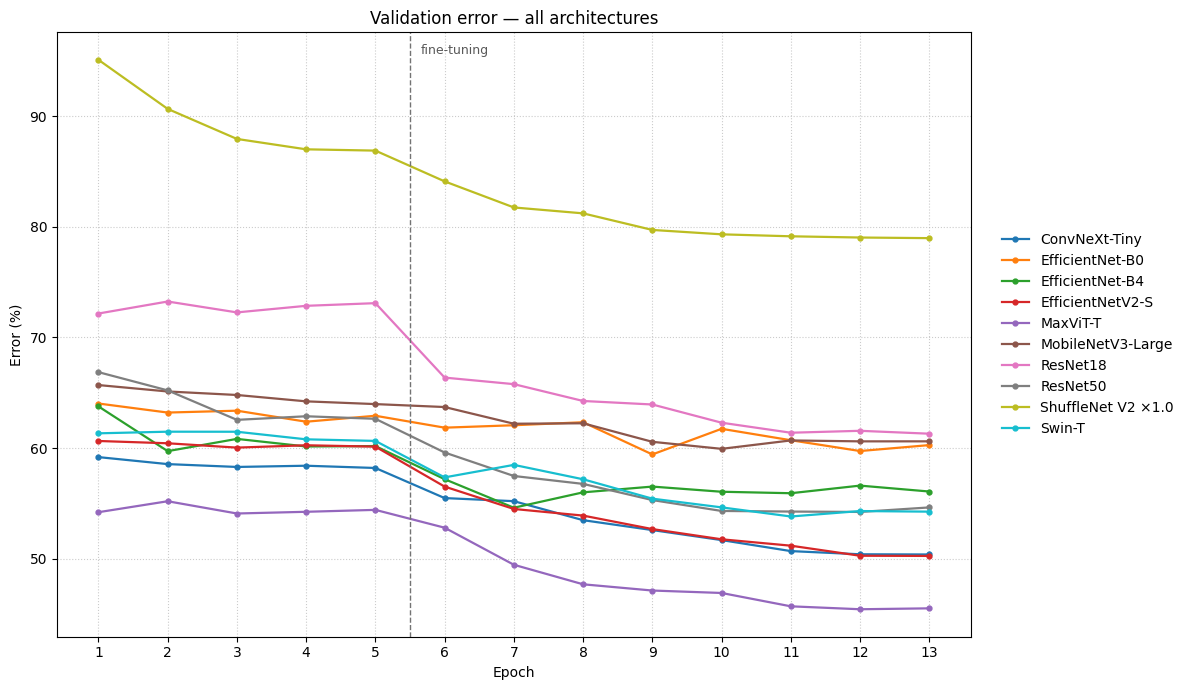

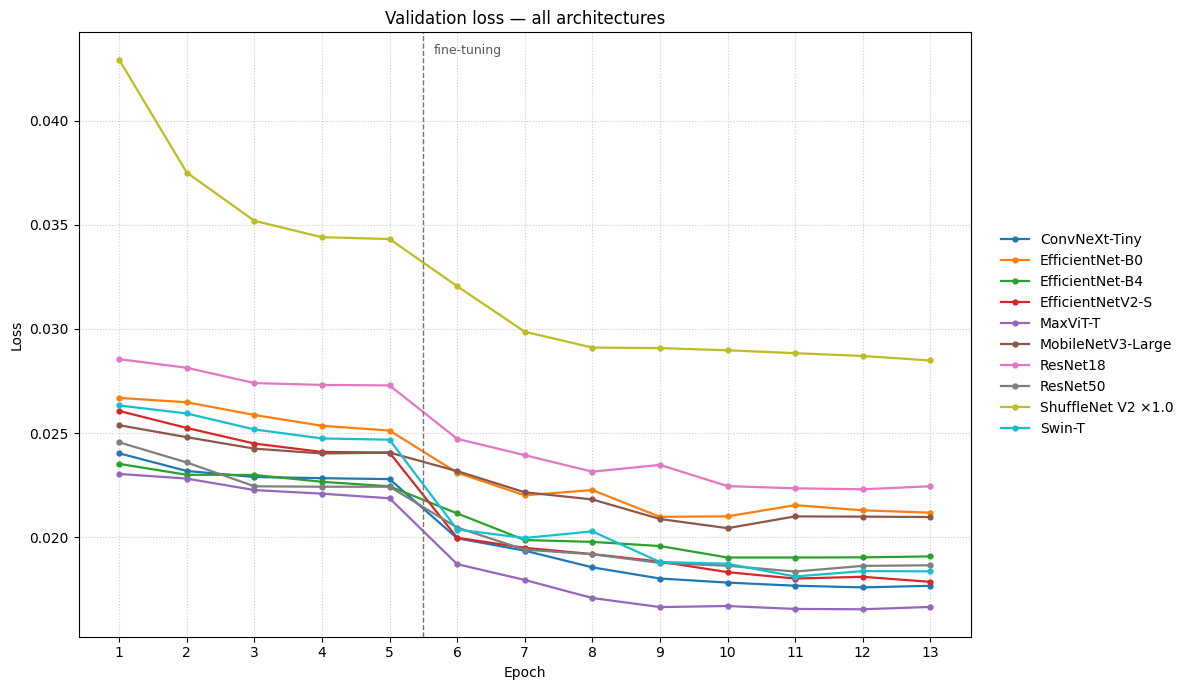

In [4]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt

DISPLAY = {
    "shufflenet_v2_x1_0": "ShuffleNet V2 ×1.0",
    "mobilenet_v3_large": "MobileNetV3-Large",
    "efficientnet_b0": "EfficientNet-B0",
    "resnet18": "ResNet18",
    "resnet50": "ResNet50",
    "efficientnet_b4": "EfficientNet-B4",
    "convnext_tiny": "ConvNeXt-Tiny",
    "swin_t": "Swin-T",
    "maxvit_t": "MaxViT-T",
    "efficientnet_v2_s": "EfficientNetV2-S",
    "vgg16": "VGG16",
}


def load_column(path: Path, column: str):
    with path.open(newline="") as handle:
        return [float(row[column]) for row in csv.DictReader(handle)]


root = Path("outputs") / "notebooks"
curves = []
for model_dir in sorted(p for p in root.iterdir() if p.is_dir()):
    baseline = model_dir / "history_baseline.csv"
    finetune = model_dir / "history_finetune.csv"
    if not baseline.is_file() or not finetune.is_file():
        continue
    curves.append(
        {
            "name": DISPLAY.get(model_dir.name, model_dir.name),
            "error": load_column(baseline, "val_error") + load_column(finetune, "val_error"),
            "loss": load_column(baseline, "val_loss") + load_column(finetune, "val_loss"),
            "n_baseline": len(load_column(baseline, "val_error")),
        }
    )

curves.sort(key=lambda row: row["name"])
boundary = curves[0]["n_baseline"]
if any(row["n_baseline"] != boundary for row in curves):
    raise RuntimeError("Baseline length differs across architectures; the stage line would be misleading.")


def draw(column, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(12, 7))
    for row in curves:
        y = row[column]
        ax.plot(range(1, len(y) + 1), y, marker="o", markersize=3.5, linewidth=1.6, label=row["name"])
    ax.axvline(boundary + 0.5, color="0.45", linestyle="--", linewidth=1)
    ax.text(
        boundary + 0.65,
        0.98,
        "fine-tuning",
        transform=ax.get_xaxis_transform(),
        ha="left",
        va="top",
        fontsize=9,
        color="0.35",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, max(len(row[column]) for row in curves) + 1))
    ax.grid(linestyle=":", alpha=0.65)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout()
    out = Path("outputs") / "report"
    out.mkdir(parents=True, exist_ok=True)
    fig.savefig(out / filename, dpi=140, bbox_inches="tight")
    plt.show()


draw("error", "Error (%)", "Validation error — all architectures", "validation_error.png")
draw("loss", "Loss", "Validation loss — all architectures", "validation_loss.png")


<a id="bibliography"></a>

## 5. Bibliography

- T.-Y. Lin, M. Maire, S. Belongie, J. Hays, P. Perona, D. Ramanan, P. Dollár, and C. L. Zitnick. *Microsoft COCO: Common Objects in Context.* ECCV, 2014.
- R. Kéchichian. *The MS COCO classification challenge.* Course notebook, IAV, INSA Lyon. Defines the F1 score, the dataset layout, and the ban on any other MS COCO distribution.
- Torchvision models and weights. <https://docs.pytorch.org/vision/main/models.html>. Source of the parameter counts, GFLOPs, and ImageNet top-1 figures in section 3.
- E. Ben-Baruch, T. Ridnik, N. Zamir, et al. *Asymmetric Loss For Multi-Label Classification.* ICCV, 2021.
- K. Sechidis, G. Tsoumakas, and I. Vlahavas. *On the Stratification of Multi-label Data.* ECML PKDD, 2011.
- T.-Y. Lin, P. Goyal, R. Girshick, K. He, and P. Dollár. *Focal Loss for Dense Object Detection.* ICCV, 2017. The head bias is initialized from the class prevalence, following the same idea.
- I. Loshchilov and F. Hutter. *Decoupled Weight Decay Regularization.* ICLR, 2019.
